# 03 · Clustering — K-Means & Hierarchical

**Input:** `data/processed/features_dataset.csv`  
**Output:** `data/processed/final_segmented_dataset.csv`  
**Models saved:** `models/clustering_model.pkl`, `models/scaler.pkl`, `models/cluster_mapping.pkl`, `models/feature_columns.pkl`

**Design:**
- K-Means: efficient, scalable, dashboard-integrated
- Hierarchical: dendrogram-based validation of K-Means results
- Auto-labelling: cluster names assigned by composite rank score — no manual mapping
- Ranking: lowest → Budget · middle → Mainstream · highest → Premium

## 1 · Imports

In [195]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
print('Libraries loaded')

Libraries loaded


## 2 · Load Data

In [196]:
df = pd.read_csv('../data/processed/features_dataset.csv')
df = df.dropna()

print('Shape:', df.shape)
df.head()

Shape: (7305, 17)


,sale_price,floor_area_sqft,price_per_sqft,investment_score,loan_indicator,satisfaction_score,age,unit_type_encoded,client_id,country,region,unit_category,acquisition_purpose,client_type,referral_channel,gender,loan_applied
0,351419.29,1090.32,322.308396,5.739344,1,4,58,0,C0001,USA,California,Apartment,Home,Individual,Website,F,Yes
1,496266.41,1608.84,308.462252,7.115746,1,4,58,0,C0001,USA,California,Apartment,Home,Individual,Website,F,Yes
2,175599.90,522.71,335.941344,4.068629,1,4,58,0,C0001,USA,California,Apartment,Home,Individual,Website,F,Yes
3,223479.12,713.67,313.140695,4.523599,1,4,58,0,C0001,USA,California,Apartment,Home,Individual,Website,F,Yes
4,299245.20,938.57,318.830988,3.443562,0,1,64,0,C0002,USA,California,Apartment,Home,Individual,Website,M,No


## 3 · Select & Scale Model Features

In [197]:
MODEL_FEATURES = [
    'sale_price',
    'floor_area_sqft',
    'price_per_sqft',
    'investment_score',
    'loan_indicator',
    'satisfaction_score',
    'age',
    'unit_type_encoded',
]

training_df = df[MODEL_FEATURES].copy()

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(training_df)

print('Training shape:', training_df.shape)
print('Features:', MODEL_FEATURES)

Training shape: (7305, 8)
Features: ['sale_price', 'floor_area_sqft', 'price_per_sqft', 'investment_score', 'loan_indicator', 'satisfaction_score', 'age', 'unit_type_encoded']


## 4 · Optimal Cluster Selection (PRD Step 5)

### 4a · Elbow Method

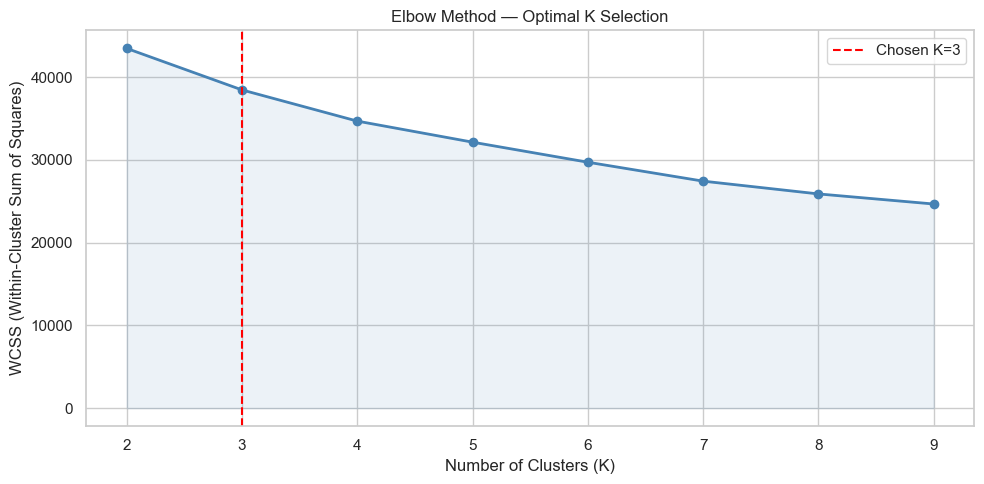

In [198]:
wcss = []
K_RANGE = range(2, 10)

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(list(K_RANGE), wcss, marker='o', linewidth=2, color='steelblue')
plt.fill_between(list(K_RANGE), wcss, alpha=0.1, color='steelblue')
plt.axvline(x=3, color='red', linestyle='--', label='Chosen K=3')
plt.title('Elbow Method — Optimal K Selection')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.legend()
plt.tight_layout()
plt.show()

### 4b · Silhouette Scores

In [199]:
sil_scores = []
db_scores  = []

print('K   Silhouette   Davies-Bouldin')
print('-' * 38)
for k in K_RANGE:
    labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_scaled)
    sil    = silhouette_score(X_scaled, labels)
    db     = davies_bouldin_score(X_scaled, labels)
    sil_scores.append(sil)
    db_scores.append(db)
    print(f'{k:<5} {sil:.4f}       {db:.4f}')

K   Silhouette   Davies-Bouldin
--------------------------------------
2     0.2339       1.6367
3     0.2375       1.5204
4     0.1812       1.6970
5     0.1787       1.5769
6     0.1906       1.5638
7     0.1930       1.6235
8     0.1870       1.5328
9     0.1854       1.5567


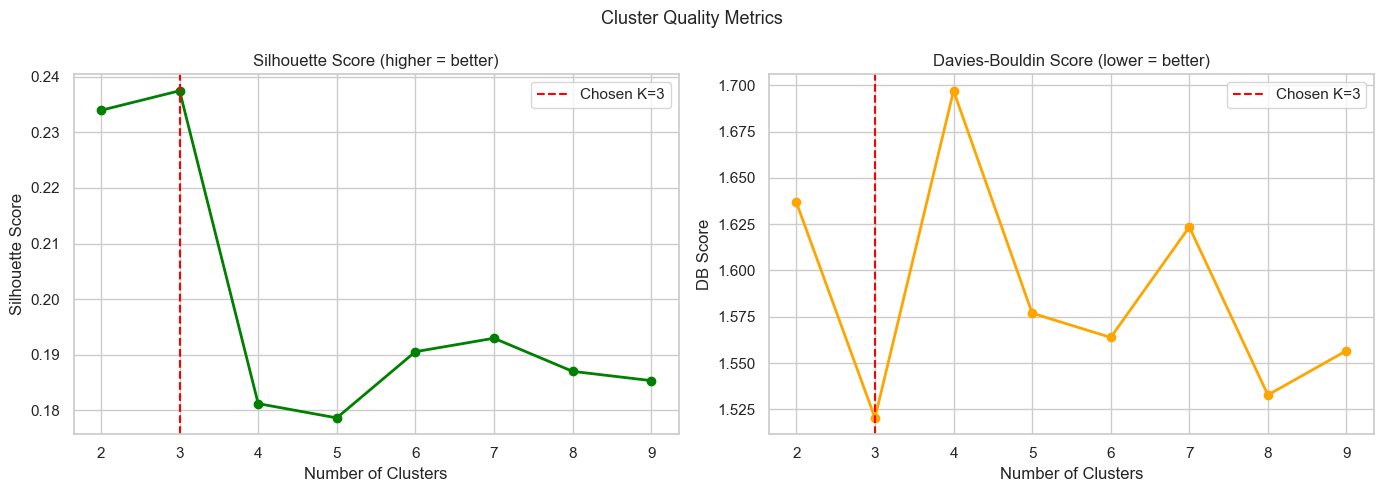

In [200]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Silhouette — higher is better
axes[0].plot(list(K_RANGE), sil_scores, marker='o', color='green', linewidth=2)
axes[0].axvline(x=3, color='red', linestyle='--', label='Chosen K=3')
axes[0].set_title('Silhouette Score (higher = better)')
axes[0].set_xlabel('Number of Clusters')
axes[0].set_ylabel('Silhouette Score')
axes[0].legend()

# Davies-Bouldin — lower is better
axes[1].plot(list(K_RANGE), db_scores, marker='o', color='orange', linewidth=2)
axes[1].axvline(x=3, color='red', linestyle='--', label='Chosen K=3')
axes[1].set_title('Davies-Bouldin Score (lower = better)')
axes[1].set_xlabel('Number of Clusters')
axes[1].set_ylabel('DB Score')
axes[1].legend()

plt.suptitle('Cluster Quality Metrics', fontsize=13)
plt.tight_layout()
plt.show()

## 5 · K-Means Clustering (PRD Step 4)

In [201]:
N_CLUSTERS = 4  # ← change here for a different K

kmeans   = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

print('K-Means done')
print('Cluster counts:', pd.Series(clusters).value_counts().sort_index().to_dict())
print(f'Final Silhouette Score: {silhouette_score(X_scaled, clusters):.4f}')

K-Means done
Cluster counts: {0: 1016, 1: 1981, 2: 2026, 3: 2282}
Final Silhouette Score: 0.1812


## 6 · Automatic Cluster Labelling

Algorithm:
1. Compute mean of ranking metrics per cluster
2. Normalise to 0–1 (no single metric dominates)
3. Average into one composite rank score
4. Sort clusters lowest → highest
5. Assign: Budget → Mainstream → Premium

In [202]:
RANKING_METRICS = ['sale_price', 'investment_score', 'price_per_sqft', 'floor_area_sqft', 'satisfaction_score']

cluster_means = df.groupby('Cluster')[RANKING_METRICS].mean()

print('Raw cluster means:')
print(cluster_means.round(2))

Raw cluster means:
         sale_price  investment_score  price_per_sqft  floor_area_sqft  \
Cluster                                                                  
0         378891.42              5.48          315.70          1201.46   
1         260309.84              5.02          299.17           874.75   
2         252549.22              3.44          296.53           855.49   
3         485740.04              6.51          304.52          1599.17   

         satisfaction_score  
Cluster                      
0                      3.13  
1                      4.24  
2                      1.74  
3                      3.15  


In [203]:
rank_scaler      = MinMaxScaler()
means_normalised = pd.DataFrame(
    rank_scaler.fit_transform(cluster_means),
    columns=RANKING_METRICS,
    index=cluster_means.index,
)

cluster_means['rank_score'] = means_normalised.mean(axis=1)

print('Cluster means with rank score:')
print(cluster_means.round(4).sort_values('rank_score'))

Cluster means with rank score:
          sale_price  investment_score  price_per_sqft  floor_area_sqft  \
Cluster                                                                   
2        252549.2171            3.4414        296.5276         855.4858   
1        260309.8438            5.0193        299.1687         874.7490   
0        378891.4205            5.4783        315.6994        1201.4626   
3        485740.0365            6.5064        304.5246        1599.1704   

         satisfaction_score  rank_score  
Cluster                                  
2                    1.7359      0.0000  
1                    4.2428      0.3423  
0                    3.1299      0.6455  
3                    3.1512      0.7963  


In [204]:
SEGMENT_LABELS = [
    'First-Time Buyers',
    'Corporate Buyers',
    'Global Investors',
    'Luxury Investors',
]

sorted_cluster_ids = cluster_means['rank_score'].sort_values().index.tolist()

CLUSTER_NAMES = {
    cluster_id: label
    for cluster_id, label in zip(sorted_cluster_ids, SEGMENT_LABELS)
}

print('Auto-assigned cluster mapping:')
for cluster_id, name in sorted(CLUSTER_NAMES.items()):
    score = cluster_means.loc[cluster_id, 'rank_score']
    price = cluster_means.loc[cluster_id, 'sale_price']
    print(f'  Cluster {cluster_id}  rank={score:.4f}  avg_price=${price:,.0f}  →  {name}')

Auto-assigned cluster mapping:
  Cluster 0  rank=0.6455  avg_price=$378,891  →  Global Investors
  Cluster 1  rank=0.3423  avg_price=$260,310  →  Corporate Buyers
  Cluster 2  rank=0.0000  avg_price=$252,549  →  First-Time Buyers
  Cluster 3  rank=0.7963  avg_price=$485,740  →  Luxury Investors


In [205]:
df['Buyer_Segment'] = df['Cluster'].map(CLUSTER_NAMES)

print('Verification — means by segment:')
df.groupby('Buyer_Segment')[['sale_price', 'investment_score', 'price_per_sqft', 'floor_area_sqft']].mean().round(2)

Verification — means by segment:


,sale_price,investment_score,price_per_sqft,floor_area_sqft
Buyer_Segment,,,,
Corporate Buyers,260309.84,5.02,299.17,874.75
First-Time Buyers,252549.22,3.44,296.53,855.49
Global Investors,378891.42,5.48,315.70,1201.46
Luxury Investors,485740.04,6.51,304.52,1599.17


## 7 · K-Means Cluster Visualisations

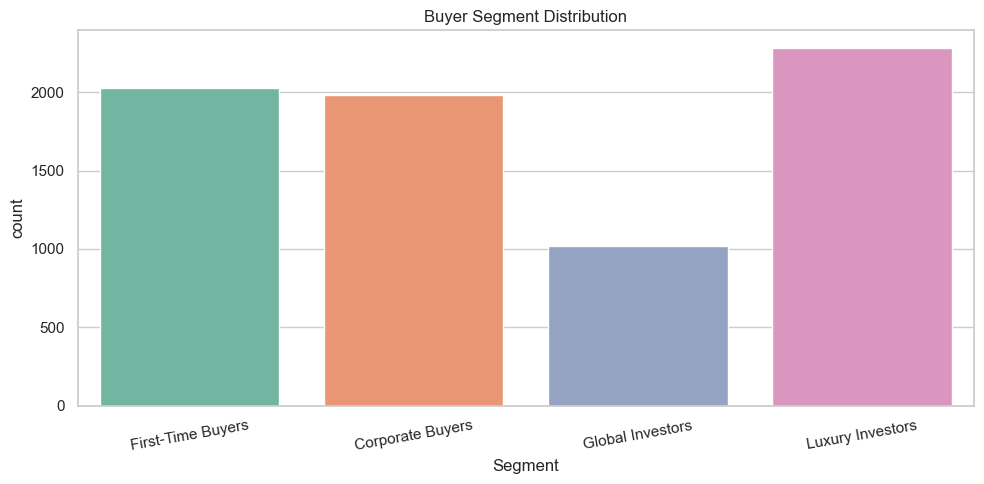

In [206]:
SEGMENT_ORDER = ['First-Time Buyers', 'Corporate Buyers', 'Global Investors', 'Luxury Investors']

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Buyer_Segment', order=SEGMENT_ORDER, palette='Set2')
plt.title('Buyer Segment Distribution')
plt.xlabel('Segment')
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

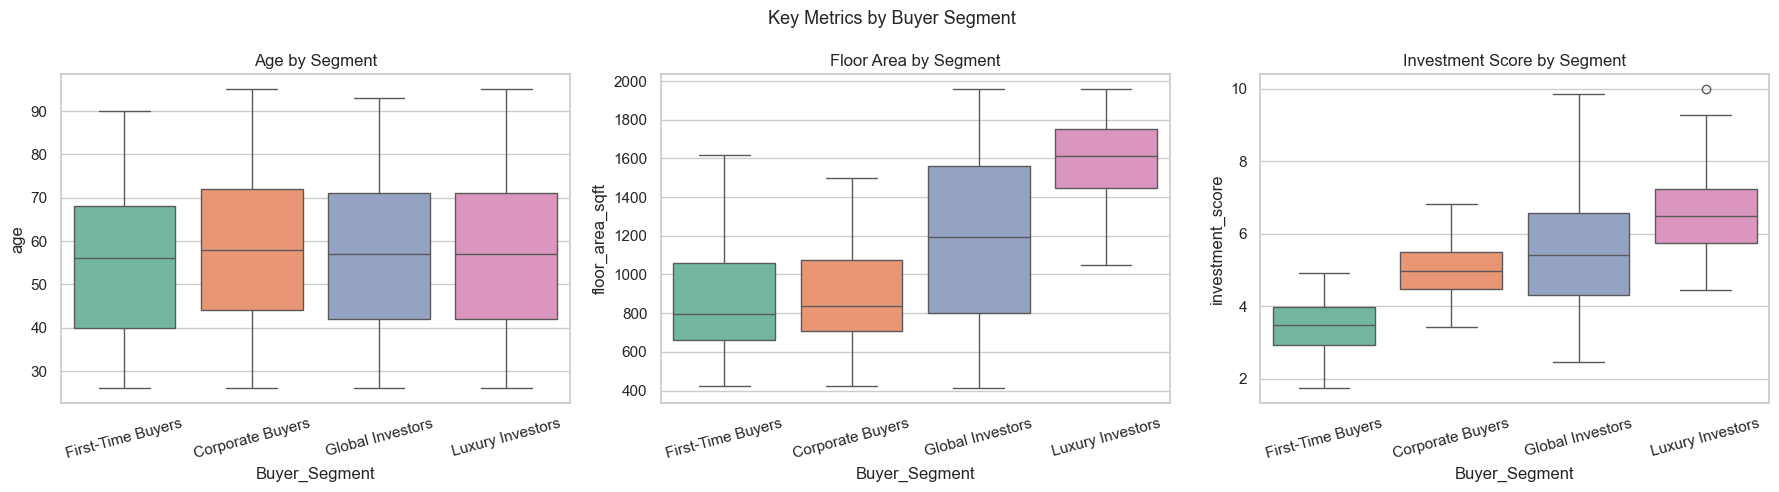

In [207]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df, x='Buyer_Segment', y='age', order=SEGMENT_ORDER, palette='Set2', ax=axes[0])
axes[0].set_title('Age by Segment')
axes[0].tick_params(axis='x', rotation=15)

sns.boxplot(data=df, x='Buyer_Segment', y='floor_area_sqft', order=SEGMENT_ORDER, palette='Set2', ax=axes[1])
axes[1].set_title('Floor Area by Segment')
axes[1].tick_params(axis='x', rotation=15)

sns.boxplot(data=df, x='Buyer_Segment', y='investment_score', order=SEGMENT_ORDER, palette='Set2', ax=axes[2])
axes[2].set_title('Investment Score by Segment')
axes[2].tick_params(axis='x', rotation=15)

plt.suptitle('Key Metrics by Buyer Segment', fontsize=13)
plt.tight_layout()
plt.show()

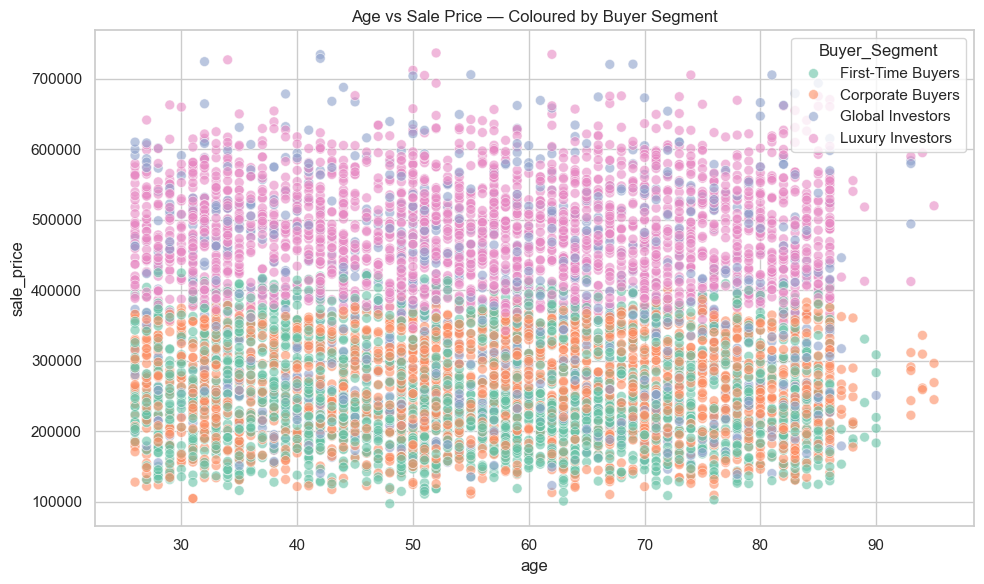

In [208]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='age',
    y='sale_price',
    hue='Buyer_Segment',
    hue_order=SEGMENT_ORDER,
    palette='Set2',
    alpha=0.6,
    s=50
)
plt.title('Age vs Sale Price — Coloured by Buyer Segment')
plt.tight_layout()
plt.show()

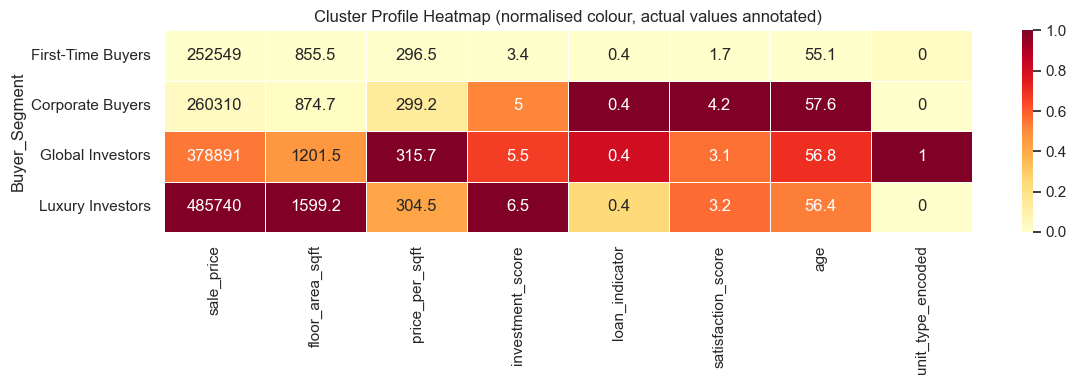

In [209]:
# Segment profile heatmap
profile = df.groupby('Buyer_Segment')[MODEL_FEATURES].mean()
profile_norm = (profile - profile.min()) / (profile.max() - profile.min())

plt.figure(figsize=(12, 4))
sns.heatmap(profile_norm.loc[SEGMENT_ORDER], annot=profile.loc[SEGMENT_ORDER].round(1),
            fmt='g', cmap='YlOrRd', linewidths=0.5)
plt.title('Cluster Profile Heatmap (normalised colour, actual values annotated)')
plt.tight_layout()
plt.show()

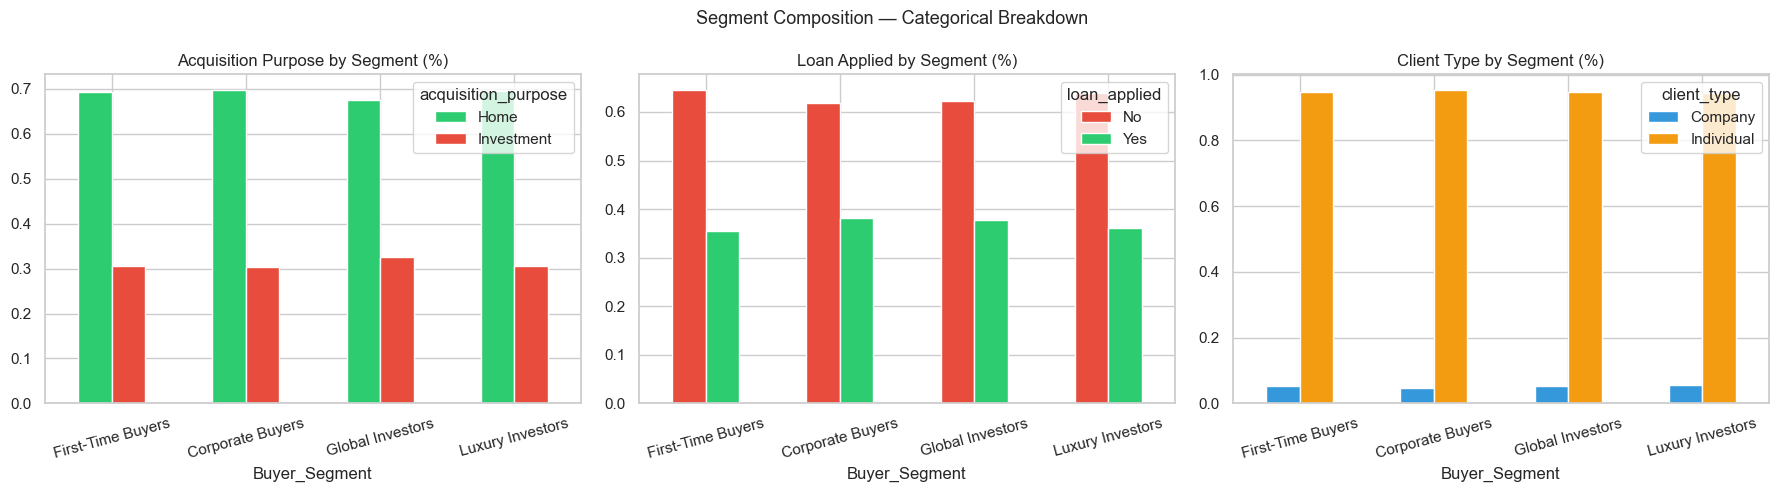

In [210]:
# Segment vs categorical features
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

pd.crosstab(df['Buyer_Segment'], df['acquisition_purpose'], normalize='index').loc[SEGMENT_ORDER].plot(
    kind='bar', ax=axes[0], color=['#2ecc71','#e74c3c'])
axes[0].set_title('Acquisition Purpose by Segment (%)')
axes[0].tick_params(axis='x', rotation=15)

pd.crosstab(df['Buyer_Segment'], df['loan_applied'], normalize='index').loc[SEGMENT_ORDER].plot(
    kind='bar', ax=axes[1], color=['#e74c3c','#2ecc71'])
axes[1].set_title('Loan Applied by Segment (%)')
axes[1].tick_params(axis='x', rotation=15)

pd.crosstab(df['Buyer_Segment'], df['client_type'], normalize='index').loc[SEGMENT_ORDER].plot(
    kind='bar', ax=axes[2], color=['#3498db','#f39c12'])
axes[2].set_title('Client Type by Segment (%)')
axes[2].tick_params(axis='x', rotation=15)

plt.suptitle('Segment Composition — Categorical Breakdown', fontsize=13)
plt.tight_layout()
plt.show()

## 8 · Hierarchical Clustering (PRD Step 4)

Hierarchical clustering is used to **validate** K-Means results. The dendrogram reveals the natural cluster structure at various granularities, confirming that K=3 is optimal.

In [211]:
# Fit Agglomerative Clustering on full data
agg = AgglomerativeClustering(n_clusters=N_CLUSTERS, linkage='ward')
df['Hierarchical_Cluster'] = agg.fit_predict(X_scaled)

hc_sil = silhouette_score(X_scaled, df['Hierarchical_Cluster'])
km_sil = silhouette_score(X_scaled, df['Cluster'])

print('=== CLUSTERING COMPARISON ===')
print(f'K-Means     Silhouette: {km_sil:.4f}')
print(f'Hierarchical Silhouette: {hc_sil:.4f}')
print()
print('Hierarchical Cluster Counts:', df['Hierarchical_Cluster'].value_counts().sort_index().to_dict())

=== CLUSTERING COMPARISON ===
K-Means     Silhouette: 0.1812
Hierarchical Silhouette: 0.1765

Hierarchical Cluster Counts: {0: 2532, 1: 2188, 2: 1080, 3: 1505}


In [212]:
# Compare K-Means vs Hierarchical assignments
from sklearn.metrics import adjusted_rand_score

ari = adjusted_rand_score(df['Cluster'], df['Hierarchical_Cluster'])
print(f'Adjusted Rand Index (K-Means vs Hierarchical): {ari:.4f}')
print('(1.0 = identical assignment, 0 = random)')

# Cross-tabulation
print('\nCluster agreement cross-tab:')
print(pd.crosstab(df['Cluster'], df['Hierarchical_Cluster'],
                  rownames=['K-Means'], colnames=['Hierarchical']))

Adjusted Rand Index (K-Means vs Hierarchical): 0.4494
(1.0 = identical assignment, 0 = random)

Cluster agreement cross-tab:
Hierarchical     0     1     2    3
K-Means                            
0                0     0  1016    0
1              244  1002     2  733
2              209  1085    62  670
3             2079   101     0  102


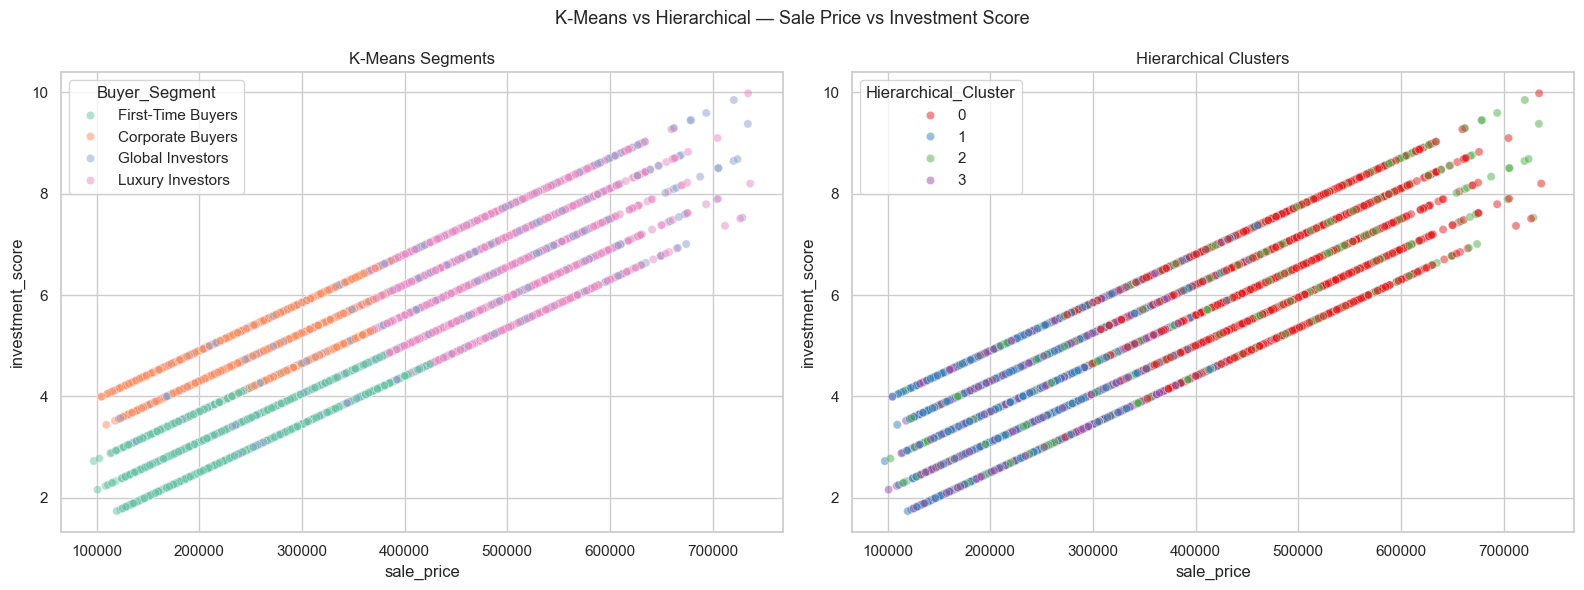

In [213]:
# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(data=df, x='sale_price', y='investment_score',
                hue='Buyer_Segment', hue_order=SEGMENT_ORDER,
                palette='Set2', alpha=0.5, ax=axes[0])
axes[0].set_title('K-Means Segments')

sns.scatterplot(data=df, x='sale_price', y='investment_score',
                hue='Hierarchical_Cluster',
                palette='Set1', alpha=0.5, ax=axes[1])
axes[1].set_title('Hierarchical Clusters')

plt.suptitle('K-Means vs Hierarchical — Sale Price vs Investment Score', fontsize=13)
plt.tight_layout()
plt.show()

## 9 · Cluster Summary (for Research Paper)

In [214]:
summary_metrics = [
    'sale_price', 'floor_area_sqft', 'price_per_sqft',
    'investment_score', 'satisfaction_score', 'age',
    'loan_indicator', 'unit_type_encoded'
]
cluster_summary = df.groupby('Buyer_Segment')[summary_metrics].agg(['mean', 'median', 'std']).round(2)
cluster_summary.columns = ['_'.join(c) for c in cluster_summary.columns]

# Add segment size
cluster_summary.insert(0, 'count', df['Buyer_Segment'].value_counts())
cluster_summary.insert(1, 'pct_total', (df['Buyer_Segment'].value_counts() / len(df) * 100).round(1))

print('Cluster Summary:')
cluster_summary

Cluster Summary:


,count,pct_total,sale_price_mean,sale_price_median,sale_price_std,floor_area_sqft_mean,floor_area_sqft_median,floor_area_sqft_std,price_per_sqft_mean,price_per_sqft_median,price_per_sqft_std,investment_score_mean,investment_score_median,investment_score_std,satisfaction_score_mean,satisfaction_score_median,satisfaction_score_std,age_mean,age_median,age_std,loan_indicator_mean,loan_indicator_median,loan_indicator_std,unit_type_encoded_mean,unit_type_encoded_median,unit_type_encoded_std
Buyer_Segment,,,,,,,,,,,,,,,,,,,,,,,,,,
Corporate Buyers,1981,27.1,260309.84,258950.34,66281.03,874.75,834.50,229.24,299.17,299.55,28.03,5.02,4.97,0.69,4.24,4.0,0.74,57.59,58.0,17.44,0.38,0.0,0.49,0.00,0.0,0.03
First-Time Buyers,2026,27.7,252549.22,240804.60,74328.08,855.49,793.56,254.07,296.53,296.89,28.49,3.44,3.48,0.70,1.74,2.0,0.75,55.10,56.0,16.99,0.35,0.0,0.48,0.03,0.0,0.17
Global Investors,1016,13.9,378891.42,370120.35,135724.34,1201.46,1196.32,409.08,315.70,313.99,34.55,5.48,5.41,1.50,3.13,3.0,1.38,56.85,57.0,17.15,0.38,0.0,0.48,1.00,1.0,0.00
Luxury Investors,2282,31.2,485740.04,482584.05,69101.74,1599.17,1610.37,199.52,304.52,303.96,28.74,6.51,6.50,0.98,3.15,3.0,1.35,56.42,57.0,17.26,0.36,0.0,0.48,0.00,0.0,0.00


In [215]:
# Save cluster summary CSV for research paper
cluster_summary.to_csv('../data/processed/cluster_summary.csv')
print('cluster_summary.csv saved')

cluster_summary.csv saved


## 10 · Save All Artifacts

In [216]:
joblib.dump(kmeans,         '../models/clustering_model.pkl')
joblib.dump(scaler,         '../models/scaler.pkl')
joblib.dump(CLUSTER_NAMES,  '../models/cluster_mapping.pkl')
joblib.dump(MODEL_FEATURES, '../models/feature_columns.pkl')

print('Models saved:')
print('  clustering_model.pkl')
print('  scaler.pkl')
print('  cluster_mapping.pkl:', CLUSTER_NAMES)
print('  feature_columns.pkl:', MODEL_FEATURES)

Models saved:
  clustering_model.pkl
  scaler.pkl
  cluster_mapping.pkl: {2: 'First-Time Buyers', 1: 'Corporate Buyers', 0: 'Global Investors', 3: 'Luxury Investors'}
  feature_columns.pkl: ['sale_price', 'floor_area_sqft', 'price_per_sqft', 'investment_score', 'loan_indicator', 'satisfaction_score', 'age', 'unit_type_encoded']


In [217]:
df.to_csv('../data/processed/final_segmented_dataset.csv', index=False)

print('final_segmented_dataset.csv saved:', df.shape)
print('Columns:', df.columns.tolist())

final_segmented_dataset.csv saved: (7305, 20)
Columns: ['sale_price', 'floor_area_sqft', 'price_per_sqft', 'investment_score', 'loan_indicator', 'satisfaction_score', 'age', 'unit_type_encoded', 'client_id', 'country', 'region', 'unit_category', 'acquisition_purpose', 'client_type', 'referral_channel', 'gender', 'loan_applied', 'Cluster', 'Buyer_Segment', 'Hierarchical_Cluster']


In [218]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

print('Silhouette Score      :', round(silhouette_score(X_scaled, clusters), 4))
print('Davies-Bouldin Score  :', round(davies_bouldin_score(X_scaled, clusters), 4))
print('Calinski-Harabasz     :', round(calinski_harabasz_score(X_scaled, clusters), 4))

Silhouette Score      : 0.1812
Davies-Bouldin Score  : 1.697
Calinski-Harabasz     : 1667.14
